# **Prediksi Tingkat Stres Mahasiswa Berdasarkan Gaya Hidup dan Aktivitas Akademik**

**Algoritma**: [Random Forest](https://www.google.com/search?q=Random+Forest)<br/>
**Dataset**: [@sridevilavanyacse/student-lifestyle-and-stress-prediction-dataset](https://www.kaggle.com/datasets/sridevilavanyacse/student-lifestyle-and-stress-prediction-dataset)

<br/>

**Anggota**

- Sabib Prastio (22.12.2598)
- Fiki Pratama (22.12.2551)


#### **Install Deps**


In [53]:
%pip install imbalanced-learn scikit-learn pandas matplotlib joblib numpy

Note: you may need to restart the kernel to use updated packages.


In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import os

from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    RandomizedSearchCV
)

from sklearn.preprocessing import LabelEncoder
from IPython.display import clear_output

#### **Read Dataset**


In [55]:
# Download Dataset
if not os.path.exists("student-lifestyle-and-stress-dataset.csv"):
    %pip install kaggle
    !kaggle datasets download -d sridevilavanyacse/student-lifestyle-and-stress-prediction-dataset
    !unzip -o student-lifestyle-and-stress-prediction-dataset.zip
    clear_output(wait=True)

# Read Dataset
df = pd.read_csv("student-lifestyle-and-stress-dataset.csv")

print("5 Data Pertama")
print(df.head())

print("\nUkuran Dataset")
print(df.shape)

print("\nInformasi Dataset")
print(df.info())

5 Data Pertama
  Student_Type  Sleep_Hours  Study_Hours  Social_Media_Hours  Attendance  \
0       school     6.868702     1.711722            3.176942         NaN   
1       school     8.519088     3.251084            3.880787   93.978465   
2      college     4.498770     6.306885            2.936172   64.421253   
3       school     8.591223     2.384922            5.222832   81.868960   
4      college     5.329293     9.345179            7.815869   85.847982   

   Exam_Pressure  Family_Support  Month  Stress_Level  
0            8.0             7.0    2.0             1  
1            6.0             4.0    3.0             1  
2            7.0             1.0   12.0             1  
3            2.0             7.0    7.0             0  
4            5.0             6.0   10.0             1  

Ukuran Dataset
(25500, 9)

Informasi Dataset
<class 'pandas.DataFrame'>
RangeIndex: 25500 entries, 0 to 25499
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  


##### Cek Missing Value & Data Duplikat


In [56]:
# Cek Missing Value
print("\nMissing Value :")
print(df.isnull().sum())

# Cek Data Duplikat
print("\nJumlah Data Duplikat :", df.duplicated().sum())


Missing Value :
Student_Type          1252
Sleep_Hours           1333
Study_Hours           1277
Social_Media_Hours    1312
Attendance            1305
Exam_Pressure         1270
Family_Support        1291
Month                 1314
Stress_Level             0
dtype: int64

Jumlah Data Duplikat : 24


## **Preprocessing**


#### **Deduplication**


In [57]:
df = df.drop_duplicates()
print("Jumlah Data Setelah Duplikat Removal :", len(df))

Jumlah Data Setelah Duplikat Removal : 25476


#### **Encoding Data Kategorikal**


In [58]:
encoders = {}

for col in df.select_dtypes(include=["object", "string"]).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

print("Dataset Setelah Encoding")
print(df.head())

Dataset Setelah Encoding
   Student_Type  Sleep_Hours  Study_Hours  Social_Media_Hours  Attendance  \
0             1     6.868702     1.711722            3.176942         NaN   
1             1     8.519088     3.251084            3.880787   93.978465   
2             0     4.498770     6.306885            2.936172   64.421253   
3             1     8.591223     2.384922            5.222832   81.868960   
4             0     5.329293     9.345179            7.815869   85.847982   

   Exam_Pressure  Family_Support  Month  Stress_Level  
0            8.0             7.0    2.0             1  
1            6.0             4.0    3.0             1  
2            7.0             1.0   12.0             1  
3            2.0             7.0    7.0             0  
4            5.0             6.0   10.0             1  


#### **Missing Value**


In [59]:
# df = df.drop("Student_Type", axis=1)
# df = df.drop("Attendance", axis=1)
# df = df.drop("Family_Support", axis=1)
# df = df.drop("Month", axis=1)

# Memisahkan Fitur dan Target
X = df.drop("Stress_Level", axis=1)
y = df["Stress_Level"]

# Mengisi missing value menggunakan median
imputer = SimpleImputer(strategy="median")

X = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
)

#### **Oversampling**


In [60]:
# Membagi Data Training dan Testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
print("Jumlah Data Training :", X_train.shape)
print("Jumlah Data Testing :", X_test.shape)

Jumlah Data Training : (20380, 8)
Jumlah Data Testing : (5096, 8)


In [61]:
# oversampling | SMOTE
smote = SMOTE(random_state=42)
X_train_resample, y_train_resample = smote.fit_resample(X_train, y_train)

print("Jumlah Data Training :", X_train.shape)
print("Jumlah Data Testing :", X_test.shape)

Jumlah Data Training : (20380, 8)
Jumlah Data Testing : (5096, 8)


## **Modeling**


In [62]:
# Membangun Model Random Forest
param_grid = {
    'n_estimators': [50, 100, 200, 300, 500, 1000],
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [5, 10, 20, 30],
    'min_samples_leaf': [2, 5, 10, 20],
    'max_features': ['sqrt'],
    'class_weight': [None, 'balanced']
}

random = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_grid,
    n_iter=200,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1,
    verbose=2,
)

random.fit(X_train_resample, y_train_resample)

print("===== HASIL RANDOMIZED SEARCH =====")
print("Best Parameters:")
print(random.best_params_)

print("\nBest Cross Validation Accuracy:")
print(round(random.best_score_, 4))

rf = random.best_estimator_

Fitting 5 folds for each of 200 candidates, totalling 1000 fits
===== HASIL RANDOMIZED SEARCH =====
Best Parameters:
{'n_estimators': 1000, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 20, 'class_weight': 'balanced'}

Best Cross Validation Accuracy:
0.8586


In [63]:
# Prediksi
y_pred = rf.predict(X_test)

## **Evaluasi Model**


In [64]:
# Evaluasi Model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("\n===== HASIL EVALUASI =====")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-Score :", round(f1, 4))


===== HASIL EVALUASI =====
Accuracy : 0.8175
Precision: 0.6991
Recall   : 0.6872
F1-Score : 0.6931


#### **ROC-AUC**


In [65]:
# Menghitung probabilitas prediksi
prob = rf.predict_proba(X_test)[:,1]

# Menghitung nilai ROC-AUC
roc = roc_auc_score(y_test, prob)

print("ROC AUC :", roc)

ROC AUC : 0.8718799890827132


#### **Classification Report**


In [66]:
# Classification Report
print("\nClassification Report")
print(classification_report(y_test, y_pred))


Classification Report
              precision    recall  f1-score   support

           0       0.87      0.87      0.87      3568
           1       0.70      0.69      0.69      1528

    accuracy                           0.82      5096
   macro avg       0.78      0.78      0.78      5096
weighted avg       0.82      0.82      0.82      5096



#### **Confusion Matrix**



Confusion Matrix


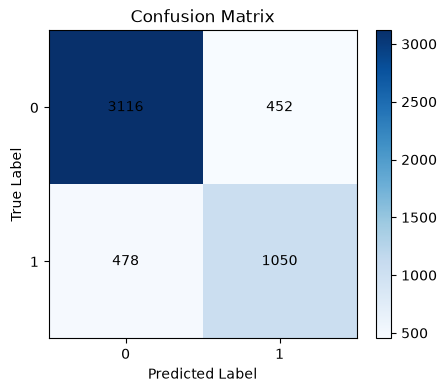

In [67]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix")

# Visualisasi Confusion Matrix
plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks([0,1])
plt.yticks([0,1])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            color="black"
        )

plt.colorbar()
plt.show()

#### **Feature Importance**



Feature Importance
              Feature  Importance
5       Exam_Pressure    0.425093
2         Study_Hours    0.124741
1         Sleep_Hours    0.093997
3  Social_Media_Hours    0.082969
4          Attendance    0.080523
6      Family_Support    0.079232
7               Month    0.062178
0        Student_Type    0.051266


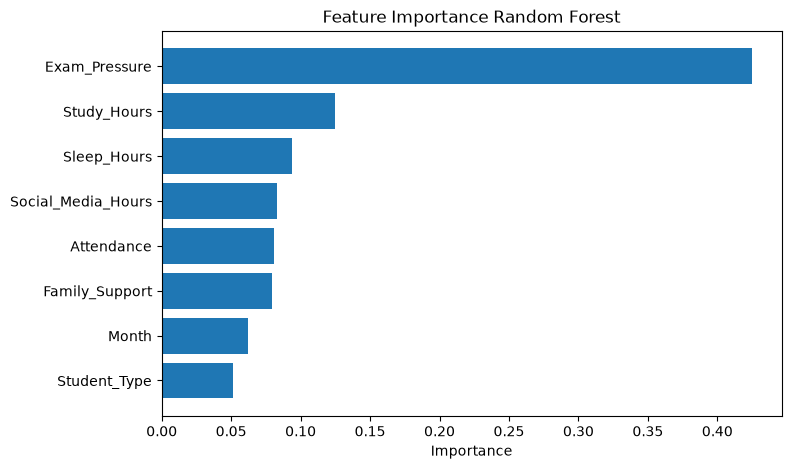

In [68]:
# Feature Importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nFeature Importance")
print(importance)


# Visualisasi Feature Importance
plt.figure(figsize=(8, 5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance Random Forest")
plt.xlabel("Importance")
plt.gca().invert_yaxis()

plt.show()

#### **10-Fold Cross Validation**


In [69]:
# 10-Fold Cross Validation
cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    rf,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("\n===== 10-Fold Cross Validation =====")
for i, score in enumerate(scores, start=1):
    print(f"Fold {i:>2} : {score:.4f} ({score*100:.2f}%)")

print("\nMean Accuracy :", round(scores.mean(), 4))
print("Std Accuracy  :", round(scores.std(), 4))

# Ringkasan Hasil
print("\n===== RINGKASAN =====")

print(f"Accuracy                 : {accuracy:.4f}")
print(f"Precision                : {precision:.4f}")
print(f"Recall                   : {recall:.4f}")
print(f"F1-Score                 : {f1:.4f}")
print(f"Mean 10-Fold Accuracy    : {scores.mean():.4f}")
print(f"Standar Deviasi Accuracy : {scores.std():.4f}")


===== 10-Fold Cross Validation =====
Fold  1 : 0.8191 (81.91%)
Fold  2 : 0.8179 (81.79%)
Fold  3 : 0.8171 (81.71%)
Fold  4 : 0.8226 (82.26%)
Fold  5 : 0.8163 (81.63%)
Fold  6 : 0.8112 (81.12%)
Fold  7 : 0.8060 (80.60%)
Fold  8 : 0.8096 (80.96%)
Fold  9 : 0.8170 (81.70%)
Fold 10 : 0.8108 (81.08%)

Mean Accuracy : 0.8148
Std Accuracy  : 0.0048

===== RINGKASAN =====
Accuracy                 : 0.8175
Precision                : 0.6991
Recall                   : 0.6872
F1-Score                 : 0.6931
Mean 10-Fold Accuracy    : 0.8148
Standar Deviasi Accuracy : 0.0048


## **Export Model**


In [70]:
joblib.dump(rf, "model.pkl")
joblib.dump(imputer, "imputer.pkl")
joblib.dump(encoders, "encoders.pkl")

['encoders.pkl']